In [12]:
!pip install -q kagglehub fuzzywuzzy python-Levenshtein joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.2 MB/s eta 0:00:00


In [13]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors

from fuzzywuzzy import process

import joblib

warnings.filterwarnings("ignore")

plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [14]:
dataset_path = kagglehub.dataset_download(
    "jealousleopard/goodreadsbooks"
)

print(dataset_path)

Using Colab cache for faster access to the 'goodreadsbooks' dataset.
/kaggle/input/goodreadsbooks


In [15]:
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(file)

books.csv


In [16]:
books = pd.read_csv(
    os.path.join(dataset_path, "books.csv"),
    on_bad_lines="skip"
)

books.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [17]:
print(f"Rows : {books.shape[0]:,}")
print(f"Columns : {books.shape[1]}")

Rows : 11,123
Columns : 12


In [18]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [19]:
books.dtypes

,0
bookID,int64
title,object
authors,object
average_rating,float64
isbn,object
isbn13,int64
language_code,object
num_pages,int64
ratings_count,int64
text_reviews_count,int64


In [20]:
books.sample(10, random_state=42)

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
8661,33439,Strawberry Shortcake Murder (Hannah Swensen #2),Joanne Fluke,3.85,1575667215,9781575667218,eng,320,14668,881,2/2/2002,Kensington
483,1537,The Oedipus Plays of Sophocles: Oedipus the Ki...,Sophocles/Paul Roche,3.97,0452011671,9780452011670,eng,288,553,46,5/1/1996,Plume
8401,32330,Air Gear Vol. 1 (Air Gear #1),Oh! Great/大暮 維人,3.92,0345492781,9780345492784,eng,224,1875,37,7/25/2006,Del Rey
6380,24010,"Laguna I Love You: The Best of ""Our Town""",John Weld/Phil Interlandi,0.00,1564741575,9781564741578,eng,285,0,0,3/1/1996,Fithian Press
1844,6544,The Scarpetta Collection: All That Remains / C...,Patricia Cornwell,4.16,074325581X,9780743255813,eng,672,30,2,11/11/2003,Scribner
398,1365,The Histories,Herodotus/Carolyn Dewald/Robin Waterfield,3.99,0192824252,9780192824257,eng,772,271,41,11/19/1998,Oxford University Press
1118,3774,The Subterraneans,Jack Kerouac,3.68,0141184892,9780141184890,eng,192,426,42,9/6/2007,Penguin Books Ltd
11005,45169,Step on a Crack (Michael Bennett #1),James Patterson/Michael Ledwidge,4.01,0316013943,9780316013949,eng,383,37552,1592,2/6/2007,Little Brown and Company
8756,33751,Die Naschkatzen,Jennifer Crusie,3.94,3442448964,9783442448968,ger,480,15,1,4/1/2001,Goldmann Verlag
3445,12564,Sometimes a Great Notion,Ken Kesey/Charles Bowden,4.17,0143039865,9780143039860,eng,715,577,80,8/29/2006,Penguin Classics


In [21]:
books.columns.tolist()

['bookID',
 'title',
 'authors',
 'average_rating',
 'isbn',
 'isbn13',
 'language_code',
 '  num_pages',
 'ratings_count',
 'text_reviews_count',
 'publication_date',
 'publisher']

In [22]:
books.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
bookID,11123.0,NaN,NaN,NaN,21310.856963,13094.727252,1.0,10277.5,20287.0,32104.5,45641.0
title,11123,10348,The Brothers Karamazov,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authors,11123,6639,Stephen King,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
average_rating,11123.0,NaN,NaN,NaN,3.934075,0.350485,0.0,3.77,3.96,4.14,5.0
isbn,11123,11123,8497646983,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
isbn13,11123.0,NaN,NaN,NaN,9759880247639.154297,442975846058.353027,8987059752.0,9780345453803.5,9780582461536.0,9780872208045.5,9790007672386.0
language_code,11123,27,eng,8908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_pages,11123.0,NaN,NaN,NaN,336.405556,241.152626,0.0,192.0,299.0,416.0,6576.0
ratings_count,11123.0,NaN,NaN,NaN,17942.848063,112499.153471,0.0,104.0,745.0,5000.5,4597666.0
text_reviews_count,11123.0,NaN,NaN,NaN,542.048099,2576.619589,0.0,9.0,47.0,238.0,94265.0


In [23]:
memory = books.memory_usage(deep=True).sum() / 1024**2

print(f"Dataset Memory Usage : {memory:.2f} MB")

Dataset Memory Usage : 4.73 MB


In [24]:
# ============================================================
# Create a Working Copy
# ============================================================

books_df = books.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [25]:
# ============================================================
# Create a Working Copy
# ============================================================

books_df = books.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [26]:
# ============================================================
# Missing Values Analysis
# ============================================================

missing_values = books_df.isnull().sum()

missing_df = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
    .reset_index()
)

missing_df.columns = ["Column", "Missing Values"]

missing_df

,Column,Missing Values


In [27]:
# ============================================================
# Missing Values Visualization
# ============================================================

if len(missing_df) > 0:

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=missing_df,
        x="Missing Values",
        y="Column"
    )

    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()

else:
    print("No Missing Values Found.")

No Missing Values Found.


In [28]:
# ============================================================
# Duplicate Records
# ============================================================

duplicate_count = books_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count}")

Duplicate Rows : 0


In [29]:
# ============================================================
# Remove Duplicate Records
# ============================================================

books_df.drop_duplicates(inplace=True)

print("New Shape :", books_df.shape)

New Shape : (11123, 12)


In [32]:
# ============================================================
# Correct Data Types
# ============================================================

numeric_columns = [
    "average_rating",
    "ratings_count",
    "text_reviews_count",
    "  num_pages" # Corrected column name
]

for col in numeric_columns:

    books_df[col] = pd.to_numeric(
        books_df[col],
        errors="coerce"
    )

books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  object 
 2   authors             11123 non-null  object 
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  object 
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  object 
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  object 
 11  publisher           11123 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 1.0+ MB


In [33]:
# ============================================================
# Remove Invalid Numeric Records
# ============================================================

books_df = books_df.dropna(
    subset=numeric_columns
)

books_df.reset_index(
    drop=True,
    inplace=True
)

print(books_df.shape)

(11123, 12)


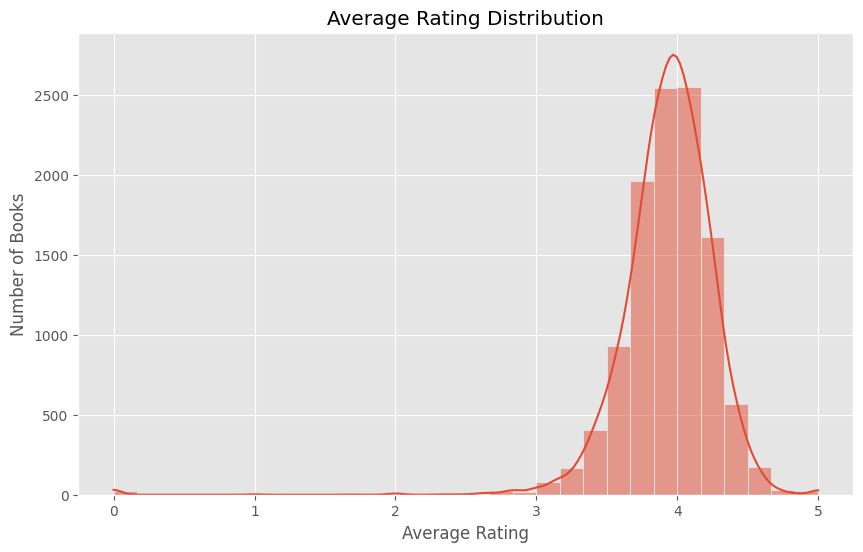

In [34]:
# ============================================================
# Distribution of Average Ratings
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    books_df["average_rating"],
    bins=30,
    kde=True
)

plt.title("Average Rating Distribution")

plt.xlabel("Average Rating")

plt.ylabel("Number of Books")

plt.show()

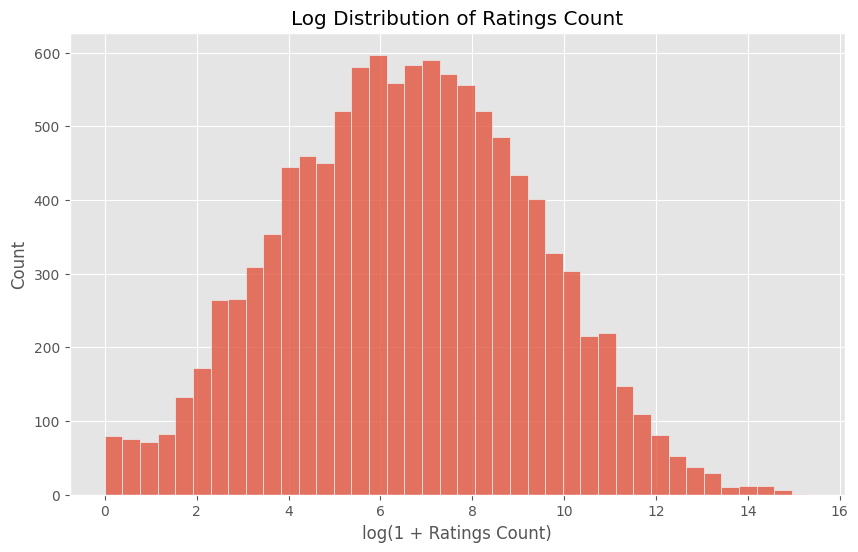

In [35]:
# ============================================================
# Ratings Count Distribution
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    np.log1p(books_df["ratings_count"]),
    bins=40
)

plt.title("Log Distribution of Ratings Count")

plt.xlabel("log(1 + Ratings Count)")

plt.show()

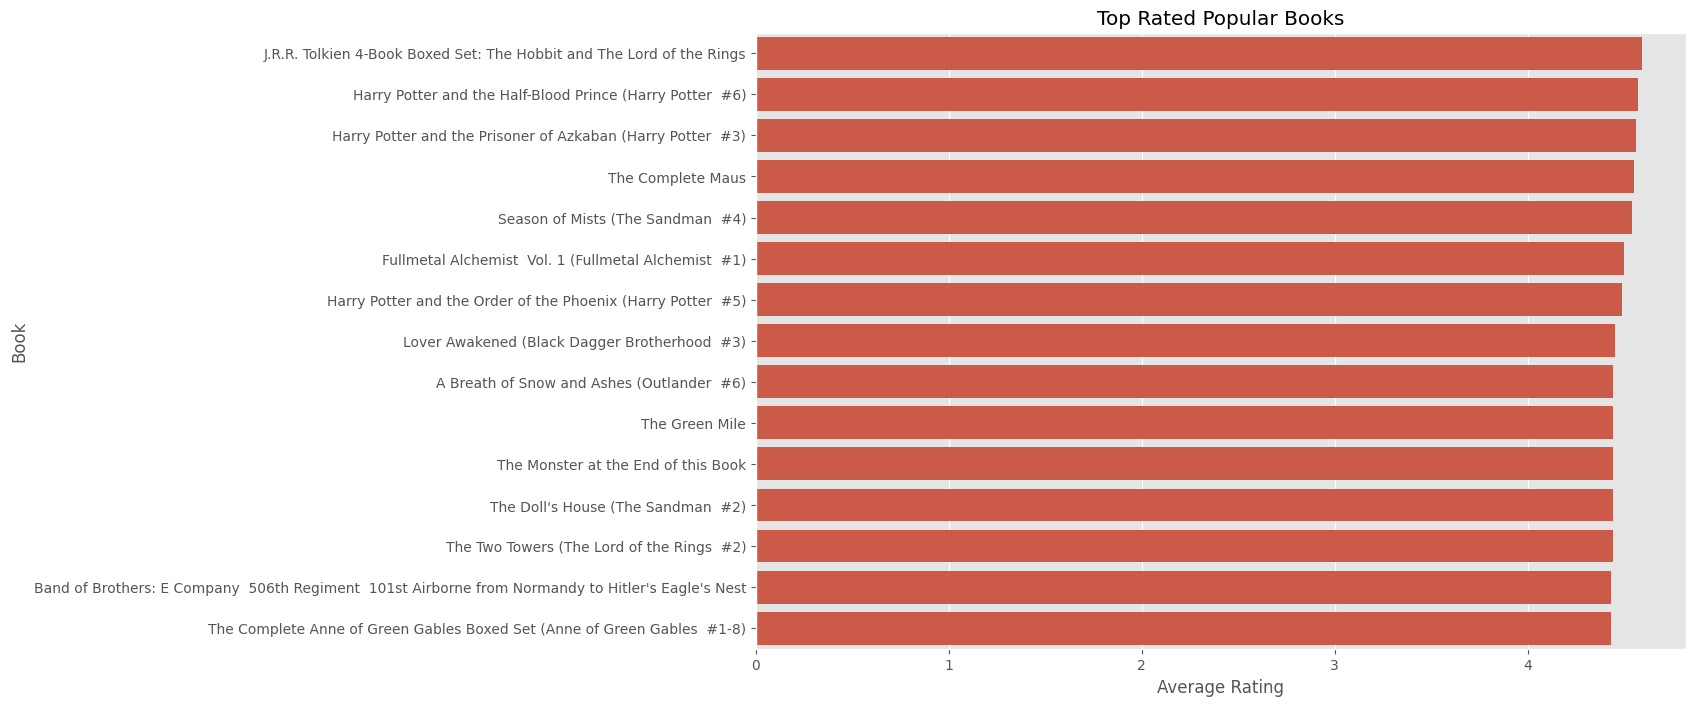

In [36]:
# ============================================================
# Highest Rated Popular Books
# ============================================================

popular_books = books_df[
    books_df["ratings_count"] >= 50000
]

top_books = (
    popular_books
    .sort_values(
        "average_rating",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top_books,
    x="average_rating",
    y="title"
)

plt.title("Top Rated Popular Books")

plt.xlabel("Average Rating")

plt.ylabel("Book")

plt.show()

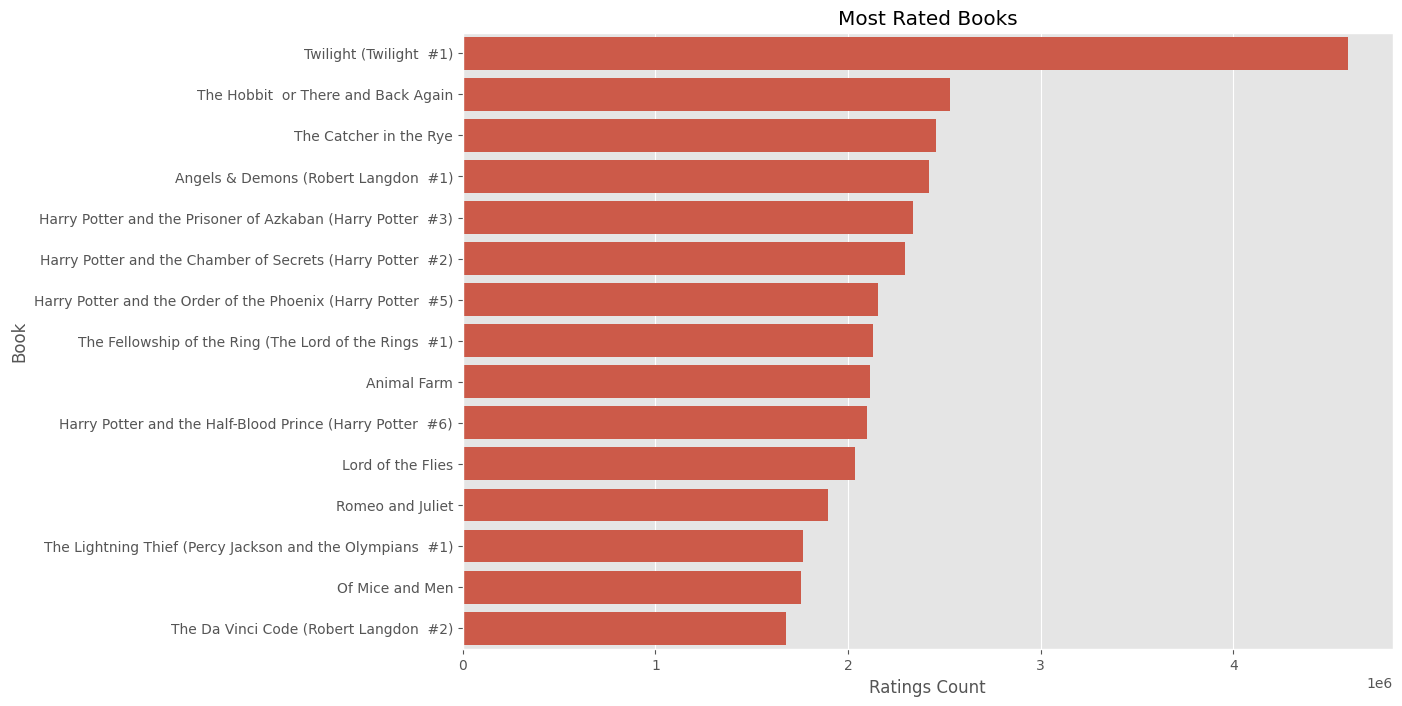

In [37]:
# ============================================================
# Most Rated Books
# ============================================================

most_rated = (
    books_df
    .sort_values(
        "ratings_count",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=most_rated,
    x="ratings_count",
    y="title"
)

plt.title("Most Rated Books")

plt.xlabel("Ratings Count")

plt.ylabel("Book")

plt.show()

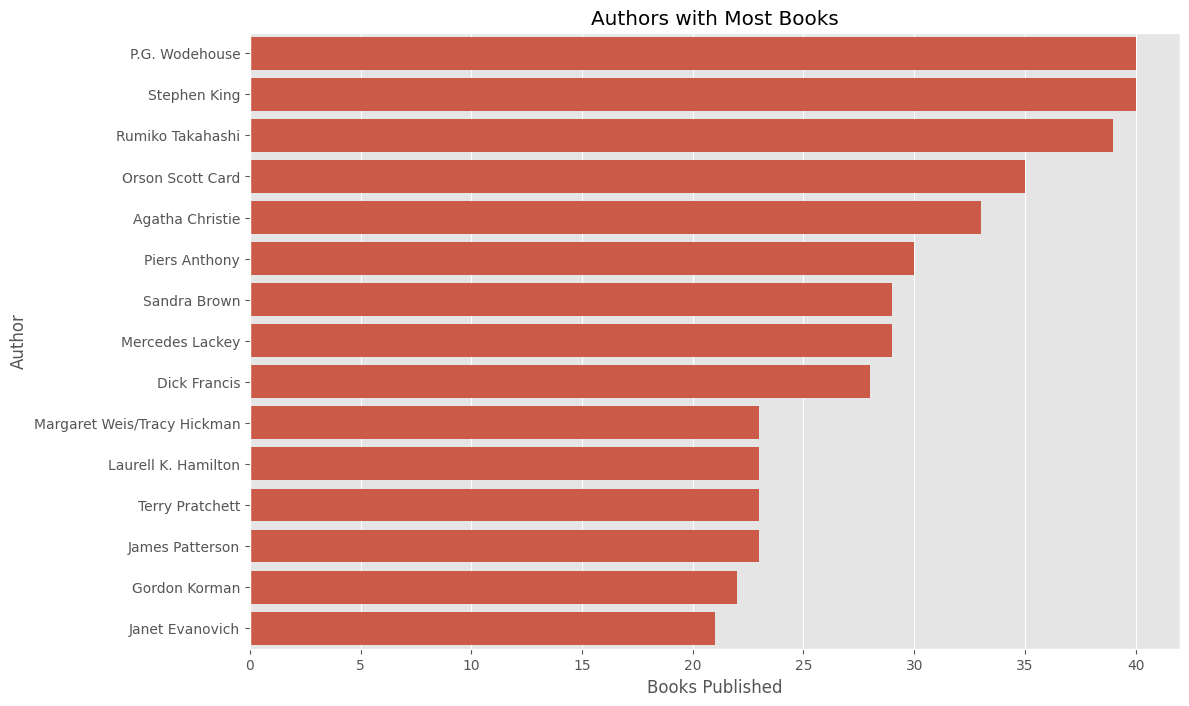

In [38]:
# ============================================================
# Authors with Most Books
# ============================================================

top_authors = (
    books_df
    .groupby("authors")
    .size()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_authors.values,
    y=top_authors.index
)

plt.title("Authors with Most Books")

plt.xlabel("Books Published")

plt.ylabel("Author")

plt.show()

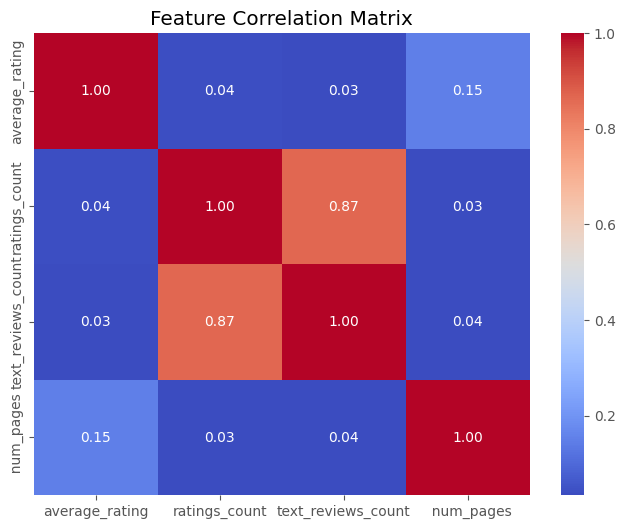

In [40]:
# ============================================================
# Numerical Feature Correlation
# ============================================================

corr = books_df[
    [
        "average_rating",
        "ratings_count",
        "text_reviews_count",
        "  num_pages"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

plt.show()

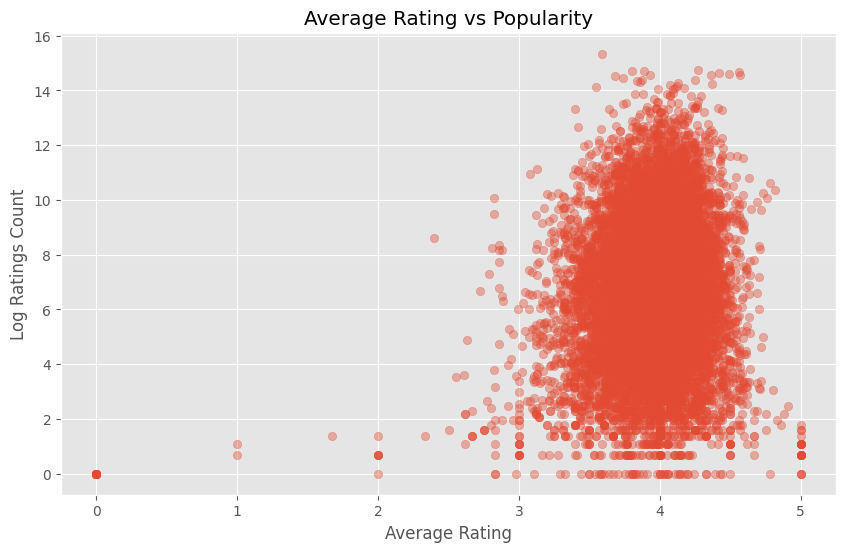

In [41]:
# ============================================================
# Rating vs Popularity
# ============================================================

plt.figure(figsize=(10,6))

plt.scatter(
    books_df["average_rating"],
    np.log1p(books_df["ratings_count"]),
    alpha=0.4
)

plt.xlabel("Average Rating")

plt.ylabel("Log Ratings Count")

plt.title("Average Rating vs Popularity")

plt.show()

In [44]:
# ============================================================
# Select Features Required for Recommendation
# ============================================================

selected_columns = [
    "title",
    "authors",
    "average_rating",
    "ratings_count",
    "text_reviews_count",
    "  num_pages",
    "language_code",
    "publisher"
]

model_df = books_df[selected_columns].copy()

print(model_df.shape)

model_df.head()

(11123, 8)


,title,authors,average_rating,ratings_count,text_reviews_count,num_pages,language_code,publisher
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,2095690,27591,652,eng,Scholastic Inc.
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,2153167,29221,870,eng,Scholastic Inc.
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,6333,244,352,eng,Scholastic
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585,36325,435,eng,Scholastic Inc.
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428,164,2690,eng,Scholastic


In [45]:
# ============================================================
# Create Rating Categories
# ============================================================

rating_bins = [0, 2, 3, 4, 5]

rating_labels = [
    "Poor",
    "Average",
    "Good",
    "Excellent"
]

model_df["rating_category"] = pd.cut(
    model_df["average_rating"],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

model_df.head()

,title,authors,average_rating,ratings_count,text_reviews_count,num_pages,language_code,publisher,rating_category
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,2095690,27591,652,eng,Scholastic Inc.,Excellent
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,2153167,29221,870,eng,Scholastic Inc.,Excellent
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,6333,244,352,eng,Scholastic,Excellent
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585,36325,435,eng,Scholastic Inc.,Excellent
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428,164,2690,eng,Scholastic,Excellent


In [46]:
# ============================================================
# Popularity Score
# ============================================================

model_df["popularity_score"] = np.log1p(
    model_df["ratings_count"]
)

model_df.head()

,title,authors,average_rating,ratings_count,text_reviews_count,num_pages,language_code,publisher,rating_category,popularity_score
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,2095690,27591,652,eng,Scholastic Inc.,Excellent,14.555394
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,2153167,29221,870,eng,Scholastic Inc.,Excellent,14.582451
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,6333,244,352,eng,Scholastic,Excellent,8.753687
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585,36325,435,eng,Scholastic Inc.,Excellent,14.665485
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428,164,2690,eng,Scholastic,Excellent,10.631736


In [47]:
# ============================================================
# Review Density
# ============================================================

model_df["review_density"] = (
    model_df["text_reviews_count"]
    /
    (model_df["ratings_count"] + 1)
)

model_df.head()

,title,authors,average_rating,ratings_count,text_reviews_count,num_pages,language_code,publisher,rating_category,popularity_score,review_density
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,2095690,27591,652,eng,Scholastic Inc.,Excellent,14.555394,0.013166
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,2153167,29221,870,eng,Scholastic Inc.,Excellent,14.582451,0.013571
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,6333,244,352,eng,Scholastic,Excellent,8.753687,0.038522
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585,36325,435,eng,Scholastic Inc.,Excellent,14.665485,0.015526
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428,164,2690,eng,Scholastic,Excellent,10.631736,0.003959


In [49]:
# ============================================================
# Categorize Books by Length
# ============================================================

page_bins = [
    0,
    150,
    300,
    500,
    3000
]

page_labels = [
    "Short",
    "Medium",
    "Long",
    "Very Long"
]

model_df["page_category"] = pd.cut(
    model_df["  num_pages"],
    bins=page_bins,
    labels=page_labels
)

model_df.head()

,title,authors,average_rating,ratings_count,text_reviews_count,num_pages,language_code,publisher,rating_category,popularity_score,review_density,page_category
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,2095690,27591,652,eng,Scholastic Inc.,Excellent,14.555394,0.013166,Very Long
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,2153167,29221,870,eng,Scholastic Inc.,Excellent,14.582451,0.013571,Very Long
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,6333,244,352,eng,Scholastic,Excellent,8.753687,0.038522,Long
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,2339585,36325,435,eng,Scholastic Inc.,Excellent,14.665485,0.015526,Long
4,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,41428,164,2690,eng,Scholastic,Excellent,10.631736,0.003959,Very Long


In [50]:
# ============================================================
# One-Hot Encode Languages
# ============================================================

language_features = pd.get_dummies(
    model_df["language_code"],
    prefix="lang"
)

language_features.head()

,lang_ale,lang_ara,lang_en-CA,lang_en-GB,lang_en-US,lang_eng,lang_enm,lang_fre,lang_ger,lang_gla,...,lang_nl,lang_nor,lang_por,lang_rus,lang_spa,lang_srp,lang_swe,lang_tur,lang_wel,lang_zho
0,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [51]:
# ============================================================
# One-Hot Encode Rating Category
# ============================================================

rating_features = pd.get_dummies(
    model_df["rating_category"],
    prefix="rating"
)

rating_features.head()

,rating_Poor,rating_Average,rating_Good,rating_Excellent
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True


In [52]:
# ============================================================
# One-Hot Encode Book Length
# ============================================================

page_features = pd.get_dummies(
    model_df["page_category"],
    prefix="pages"
)

page_features.head()

,pages_Short,pages_Medium,pages_Long,pages_Very Long
0,False,False,False,True
1,False,False,False,True
2,False,False,True,False
3,False,False,True,False
4,False,False,False,True


In [54]:
# ============================================================
# Numerical Features
# ============================================================

numeric_features = model_df[
    [
        "average_rating",
        "ratings_count",
        "text_reviews_count",
        "  num_pages",
        "popularity_score",
        "review_density"
    ]
]

numeric_features.head()

,average_rating,ratings_count,text_reviews_count,num_pages,popularity_score,review_density
0,4.57,2095690,27591,652,14.555394,0.013166
1,4.49,2153167,29221,870,14.582451,0.013571
2,4.42,6333,244,352,8.753687,0.038522
3,4.56,2339585,36325,435,14.665485,0.015526
4,4.78,41428,164,2690,10.631736,0.003959


In [55]:
# ============================================================
# Combine All Features
# ============================================================

feature_matrix = pd.concat(
    [
        numeric_features,
        language_features,
        rating_features,
        page_features
    ],
    axis=1
)

feature_matrix.head()

,average_rating,ratings_count,text_reviews_count,num_pages,popularity_score,review_density,lang_ale,lang_ara,lang_en-CA,lang_en-GB,...,lang_wel,lang_zho,rating_Poor,rating_Average,rating_Good,rating_Excellent,pages_Short,pages_Medium,pages_Long,pages_Very Long
0,4.57,2095690,27591,652,14.555394,0.013166,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
1,4.49,2153167,29221,870,14.582451,0.013571,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
2,4.42,6333,244,352,8.753687,0.038522,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
3,4.56,2339585,36325,435,14.665485,0.015526,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,4.78,41428,164,2690,10.631736,0.003959,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [56]:
# ============================================================
# Normalize Features
# ============================================================

scaler = MinMaxScaler()

scaled_features = scaler.fit_transform(
    feature_matrix
)

print(scaled_features.shape)

(11123, 41)


In [57]:
# ============================================================
# Convert Scaled Features to DataFrame
# ============================================================

scaled_features = pd.DataFrame(
    scaled_features,
    columns=feature_matrix.columns
)

scaled_features.head()

,average_rating,ratings_count,text_reviews_count,num_pages,popularity_score,review_density,lang_ale,lang_ara,lang_en-CA,lang_en-GB,...,lang_wel,lang_zho,rating_Poor,rating_Average,rating_Good,rating_Excellent,pages_Short,pages_Medium,pages_Long,pages_Very Long
0,0.914,0.455816,0.292696,0.099148,0.948787,0.013166,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.898,0.468317,0.309988,0.132299,0.950550,0.013571,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,0.884,0.001377,0.002588,0.053528,0.570605,0.038522,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.912,0.508864,0.385350,0.066150,0.955963,0.015526,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.956,0.009011,0.001740,0.409063,0.693025,0.003959,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [58]:
# ============================================================
# Feature Matrix Information
# ============================================================

print("Feature Matrix Shape")

print(scaled_features.shape)

print("\nNumber of Features")

print(len(scaled_features.columns))

print("\nFeature Names")

print(scaled_features.columns.tolist())

Feature Matrix Shape
(11123, 41)

Number of Features
41

Feature Names
['average_rating', 'ratings_count', 'text_reviews_count', '  num_pages', 'popularity_score', 'review_density', 'lang_ale', 'lang_ara', 'lang_en-CA', 'lang_en-GB', 'lang_en-US', 'lang_eng', 'lang_enm', 'lang_fre', 'lang_ger', 'lang_gla', 'lang_glg', 'lang_grc', 'lang_ita', 'lang_jpn', 'lang_lat', 'lang_msa', 'lang_mul', 'lang_nl', 'lang_nor', 'lang_por', 'lang_rus', 'lang_spa', 'lang_srp', 'lang_swe', 'lang_tur', 'lang_wel', 'lang_zho', 'rating_Poor', 'rating_Average', 'rating_Good', 'rating_Excellent', 'pages_Short', 'pages_Medium', 'pages_Long', 'pages_Very Long']


In [59]:
# ============================================================
# Additional Libraries
# ============================================================

from sklearn.neighbors import NearestNeighbors

import joblib

print("Additional libraries loaded.")

Additional libraries loaded.


In [60]:
# ============================================================
# Book Title to Index Mapping
# ============================================================

book_index = pd.Series(
    model_df.index,
    index=model_df["title"]
).drop_duplicates()

print(f"Indexed {len(book_index):,} books.")

Indexed 11,123 books.


In [61]:
# ============================================================
# Compare Different Distance Metrics
# ============================================================

distance_metrics = [
    "euclidean",
    "cosine",
    "manhattan"
]

for metric in distance_metrics:

    model = NearestNeighbors(
        n_neighbors=6,
        metric=metric,
        algorithm="auto"
    )

    model.fit(scaled_features)

    print(f"{metric} metric trained successfully.")

euclidean metric trained successfully.
cosine metric trained successfully.
manhattan metric trained successfully.


In [62]:
# ============================================================
# Final Recommendation Model
# ============================================================

knn_model = NearestNeighbors(
    n_neighbors=10,
    metric="cosine",
    algorithm="brute"
)

knn_model.fit(scaled_features)

print("Recommendation model trained successfully.")

Recommendation model trained successfully.


In [63]:
# ============================================================
# Find Nearest Neighbors
# ============================================================

distances, indices = knn_model.kneighbors(
    scaled_features
)

print("Neighbor search completed.")

print(distances.shape)

print(indices.shape)

Neighbor search completed.
(11123, 10)
(11123, 10)


In [64]:
# ============================================================
# Store Neighbor Information
# ============================================================

neighbor_distances = distances
neighbor_indices = indices

print("Neighbor arrays saved.")

Neighbor arrays saved.


In [65]:
# ============================================================
# Example Similar Books
# ============================================================

sample_book = 0

print("Selected Book:\n")

print(model_df.loc[sample_book, "title"])

print("\nNearest Books:\n")

for idx in neighbor_indices[sample_book]:

    print(model_df.loc[idx, "title"])

Selected Book:

Harry Potter and the Half-Blood Prince (Harry Potter  #6)

Nearest Books:

Harry Potter and the Half-Blood Prince (Harry Potter  #6)
Harry Potter and the Order of the Phoenix (Harry Potter  #5)
Jane Eyre
The Shining
Gone with the Wind
Outlander (Outlander  #1)
The Poisonwood Bible
A Clash of Kings  (A Song of Ice and Fire  #2)
The Count of Monte Cristo
Crime and Punishment


In [66]:
# ============================================================
# Save KNN Model
# ============================================================

joblib.dump(
    knn_model,
    "book_recommendation_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [67]:
# ============================================================
# Save Feature Scaler
# ============================================================

joblib.dump(
    scaler,
    "feature_scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [68]:
# ============================================================
# Save Feature Matrix
# ============================================================

scaled_features.to_csv(
    "scaled_features.csv",
    index=False
)

print("Feature matrix exported.")

Feature matrix exported.


In [69]:
# ============================================================
# Save Metadata
# ============================================================

model_df.to_csv(
    "book_metadata.csv",
    index=False
)

print("Metadata saved.")

Metadata saved.


In [70]:
# ============================================================
# Verify Saved Files
# ============================================================

import os

files = [
    "book_recommendation_model.pkl",
    "feature_scaler.pkl",
    "scaled_features.csv",
    "book_metadata.csv"
]

for file in files:

    print(file, "✓" if os.path.exists(file) else "✗")

book_recommendation_model.pkl ✓
feature_scaler.pkl ✓
scaled_features.csv ✓
book_metadata.csv ✓


In [71]:
# ============================================================
# Reload Saved Model
# ============================================================

loaded_model = joblib.load(
    "book_recommendation_model.pkl"
)

print("Saved model loaded successfully.")

Saved model loaded successfully.


In [72]:
# ============================================================
# Import Required Library
# ============================================================

from fuzzywuzzy import process

print("Fuzzy matching loaded successfully.")

Fuzzy matching loaded successfully.


In [73]:
# ============================================================
# Create Fast Lookup Dictionary
# ============================================================

book_lookup = {
    title.lower(): idx
    for idx, title in enumerate(model_df["title"])
}

book_titles = list(model_df["title"])

print(f"Total Books Available : {len(book_titles):,}")

Total Books Available : 11,123


In [74]:
# ============================================================
# Find Closest Matching Title
# ============================================================

def find_book(query, threshold=70):

    match = process.extractOne(
        query,
        book_titles
    )

    if match is None:
        return None

    title, score = match

    if score < threshold:
        return None

    return title

In [75]:
# ============================================================
# Recommend Similar Books
# ============================================================

def recommend_books(book_name, top_n=10):

    matched_book = find_book(book_name)

    if matched_book is None:
        print("Book not found.")
        return None

    book_index = model_df[
        model_df["title"] == matched_book
    ].index[0]

    distances, neighbors = knn_model.kneighbors(
        [scaled_features.iloc[book_index]],
        n_neighbors=top_n + 1
    )

    recommendations = []

    for distance, idx in zip(
        distances[0],
        neighbors[0]
    ):

        if idx == book_index:
            continue

        recommendations.append({
            "Title": model_df.iloc[idx]["title"],
            "Author": model_df.iloc[idx]["authors"],
            "Rating": round(
                model_df.iloc[idx]["average_rating"], 2
            ),
            "Similarity": round(
                (1 - distance) * 100,
                2
            )
        })

    return pd.DataFrame(recommendations)

In [76]:
# ============================================================
# Test Recommendation Engine
# ============================================================

recommend_books(
    "Harry Potter",
    top_n=10
)

,Title,Author,Rating,Similarity
0,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,99.98
1,Jane Eyre,Charlotte Brontë/Michael Mason,4.12,99.73
2,The Shining,Stephen King,4.22,99.23
3,Gone with the Wind,Margaret Mitchell,4.29,99.23
4,Outlander (Outlander #1),Diana Gabaldon,4.23,98.90
5,The Poisonwood Bible,Barbara Kingsolver,4.06,98.82
6,A Clash of Kings (A Song of Ice and Fire #2),George R.R. Martin,4.41,98.82
7,The Count of Monte Cristo,Alexandre Dumas/Robin Buss,4.25,98.68
8,Crime and Punishment,Fyodor Dostoyevsky/David McDuff,4.21,98.38
9,American Gods (American Gods #1),Neil Gaiman,4.11,98.35


In [77]:
recommend_books(
    "The Hobbit",
    top_n=10
)

,Title,Author,Rating,Similarity
0,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,100.00
1,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,99.99
2,Man's Search for Meaning,Viktor E. Frankl/Ilse Lasch/Harold S. Kushner/...,4.36,99.99
3,Ariel: The Restored Edition,Sylvia Plath/Frieda Hughes,4.27,99.99
4,Iran Awakening: A Memoir of Revolution and Hope,Shirin Ebadi,4.14,99.99
5,America Alone: The End of the World As We Know It,Mark Steyn,4.13,99.99
6,When the Heart Waits: Spiritual Direction for ...,Sue Monk Kidd,4.13,99.99
7,Patrimony,Philip Roth,4.17,99.99
8,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,99.99
9,Going to Meet the Man,James Baldwin,4.35,99.99


In [78]:
# ============================================================
# Interactive Recommendation
# ============================================================

book_name = input("Enter Book Name : ")

recommend_books(
    book_name,
    top_n=10
)

Enter Book Name : going to meet the man


,Title,Author,Rating,Similarity
0,Ariel: The Restored Edition,Sylvia Plath/Frieda Hughes,4.27,100.00
1,D'Aulaires' Book of Norse Myths,Ingri d'Aulaire/Edgar Parin d'Aulaire/Michael ...,4.39,100.00
2,View With a Grain of Sand: Selected Poems,Wisława Szymborska/Stanisław Barańczak/Clare C...,4.33,100.00
3,Teaching to Transgress: Education as the Pract...,bell hooks,4.37,99.99
4,Wooden: A Lifetime of Observations and Reflect...,John Wooden/Steve Jamison,4.45,99.99
5,The Mating Season (Jeeves #9),P.G. Wodehouse,4.26,99.99
6,Where the Sidewalk Ends: Poems and Drawings,Shel Silverstein,4.30,99.99
7,The Dream Giver,Bruce H. Wilkinson/David Kopp/Heather Harpham ...,4.26,99.99
8,Man's Search for Meaning,Viktor E. Frankl/Ilse Lasch/Harold S. Kushner/...,4.36,99.99
9,The Hobbit,J.R.R. Tolkien,4.27,99.99


In [79]:
# ============================================================
# Pretty Display
# ============================================================

result = recommend_books(
    "Twilight",
    top_n=10
)

if result is not None:

    display(result.style.background_gradient(
        subset=["Similarity"],
        cmap="Greens"
    ))

,Title,Author,Rating,Similarity
0,A Stroke of Midnight (Merry Gentry #4),Laurell K. Hamilton,4.070000,100.000000
1,Count Zero (Sprawl #2),William Gibson,4.010000,100.000000
2,Salamandastron (Redwall #5),Brian Jacques/Gary Chalk,4.070000,100.000000
3,Body Double (Rizzoli & Isles #4),Tess Gerritsen,4.170000,99.990000
4,The Collectors (Camel Club #2),David Baldacci,4.020000,99.990000
5,Rage of a Demon King (The Serpentwar Saga #3),Raymond E. Feist,4.050000,99.990000
6,Fierce Invalids Home from Hot Climates,Tom Robbins,4.030000,99.980000
7,Blue Moon (Anita Blake Vampire Hunter #8),Laurell K. Hamilton,4.050000,99.980000
8,Burnt Offerings (Anita Blake Vampire Hunter #7),Laurell K. Hamilton,4.080000,99.980000
9,The Killing Dance (Anita Blake Vampire Hunter #6),Laurell K. Hamilton,4.130000,99.980000


In [84]:
# ============================================================
# Book Information
# ============================================================

def show_book(book_name):

    matched = find_book(book_name)

    if matched is None:
        print("Book Not Found")
        return

    row = model_df[
        model_df["title"] == matched
    ].iloc[0]

    print("="*60)
    print("Title      :", row["title"])
    print("Author     :", row["authors"])
    print("Rating     :", row["average_rating"])
    print("Pages      :", row["  num_pages"])
    print("Language   :", row["language_code"])
    print("Publisher  :", row["publisher"])
    print("="*60)

In [85]:
show_book("The Hobbit")

Title      : The Hobbit
Author     : J.R.R. Tolkien
Rating     : 4.27
Pages      : 277
Language   : eng
Publisher  : HarperCollins


In [86]:
# ============================================================
# Find Books from Same Author
# ============================================================

def books_by_author(author):

    result = model_df[
        model_df["authors"]
        .str.contains(author, case=False, na=False)
    ]

    return result[
        [
            "title",
            "average_rating"
        ]
    ].sort_values(
        "average_rating",
        ascending=False
    )

In [87]:
books_by_author("Stephen King").head(15)

,title,average_rating
9862,The Shawshank Redemption: The Shooting Script,4.64
1575,Carrie / 'Salem's Lot / The Shining,4.54
3149,The Secretary of Dreams Volume One,4.47
6693,World's End (The Sandman #8),4.47
3709,La Milla Verde,4.44
3150,The Green Mile,4.44
8650,Different Seasons,4.35
9863,Different Seasons,4.35
1571,The Stand: Das letzte Gefecht,4.34
3165,La danza de la muerte,4.34


In [88]:
# ============================================================
# Surprise Recommendation
# ============================================================

random_book = model_df.sample(1).iloc[0]["title"]

print("Random Book")

print(random_book)

recommend_books(random_book)

Random Book
Strangers on a Train


,Title,Author,Rating,Similarity
0,The Pleasure of My Company,Steve Martin,3.78,100.00
1,What Was She Thinking? [Notes on a Scandal],Zoë Heller,3.71,100.00
2,A Pale View of Hills,Kazuo Ishiguro,3.74,100.00
3,How Proust Can Change Your Life,Alain de Botton,3.76,100.00
4,Skellig (Skellig #1),David Almond,3.80,99.99
5,An Artist of the Floating World,Kazuo Ishiguro,3.76,99.99
6,The Curious Incident of the Dog in the Night-Time,Mark Haddon,3.88,99.99
7,Mutant Message Down Under,Marlo Morgan,3.79,99.99
8,The Convenient Marriage,Georgette Heyer,3.68,99.99
9,Don't Get Too Comfortable: The Indignities of ...,David Rakoff,3.72,99.99


In [89]:
# ============================================================
# Import Libraries
# ============================================================

import time

from IPython.display import display

print("Evaluation libraries loaded.")

Evaluation libraries loaded.


In [90]:
# ============================================================
# Sample Recommendation Test
# ============================================================

test_books = [
    "Harry Potter",
    "The Hobbit",
    "Twilight",
    "The Da Vinci Code",
    "The Catcher in the Rye"
]

for book in test_books:

    print("="*80)
    print(f"Recommendations for: {book}")
    print("="*80)

    display(
        recommend_books(book, top_n=5)
    )

    print()

Recommendations for: Harry Potter


,Title,Author,Rating,Similarity
0,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,99.98
1,Jane Eyre,Charlotte Brontë/Michael Mason,4.12,99.73
2,The Shining,Stephen King,4.22,99.23
3,Gone with the Wind,Margaret Mitchell,4.29,99.23
4,Outlander (Outlander #1),Diana Gabaldon,4.23,98.90



Recommendations for: The Hobbit


,Title,Author,Rating,Similarity
0,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,100.00
1,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,99.99
2,Man's Search for Meaning,Viktor E. Frankl/Ilse Lasch/Harold S. Kushner/...,4.36,99.99
3,Ariel: The Restored Edition,Sylvia Plath/Frieda Hughes,4.27,99.99
4,Iran Awakening: A Memoir of Revolution and Hope,Shirin Ebadi,4.14,99.99



Recommendations for: Twilight


,Title,Author,Rating,Similarity
0,A Stroke of Midnight (Merry Gentry #4),Laurell K. Hamilton,4.07,100.00
1,Count Zero (Sprawl #2),William Gibson,4.01,100.00
2,Salamandastron (Redwall #5),Brian Jacques/Gary Chalk,4.07,100.00
3,Body Double (Rizzoli & Isles #4),Tess Gerritsen,4.17,99.99
4,The Collectors (Camel Club #2),David Baldacci,4.02,99.99



Recommendations for: The Da Vinci Code


,Title,Author,Rating,Similarity
0,Jimmy Stewart: A Biography,Marc Eliot,3.85,100.0
1,Outposts: Journeys to the Surviving Relics of ...,Simon Winchester,3.79,100.0
2,Personal Finance for Dummies,Eric Tyson/Rich Tennant,3.77,100.0
3,Daughter of Fortune,Isabel Allende/Margaret Sayers Peden,3.91,100.0
4,A History of God: The 4 000-Year Quest of Juda...,Karen Armstrong,3.87,100.0



Recommendations for: The Catcher in the Rye


,Title,Author,Rating,Similarity
0,Lord of the Flies,William Golding,3.68,99.60
1,The Alchemist,Paulo Coelho/Alan R. Clarke/Özdemir İnce,3.86,99.49
2,The Curious Incident of the Dog in the Night-Time,Mark Haddon,3.88,99.00
3,Brave New World,Aldous Huxley,3.99,98.68
4,The Road,Cormac McCarthy,3.97,98.20


In [91]:
# ============================================================
# Average Recommendation Similarity
# ============================================================

def average_similarity(book):

    recommendations = recommend_books(book, top_n=10)

    if recommendations is None:

        return None

    return recommendations["Similarity"].mean()

In [92]:
# ============================================================
# Similarity Evaluation
# ============================================================

scores = []

for book in test_books:

    score = average_similarity(book)

    if score is not None:

        scores.append(score)

        print(
            f"{book:<30} {score:.2f}%"
        )

print("\nAverage Similarity")

print(np.mean(scores))

Harry Potter                   99.01%
The Hobbit                     99.99%
Twilight                       99.99%
The Da Vinci Code              100.00%
The Catcher in the Rye         98.27%

Average Similarity
99.45240000000001


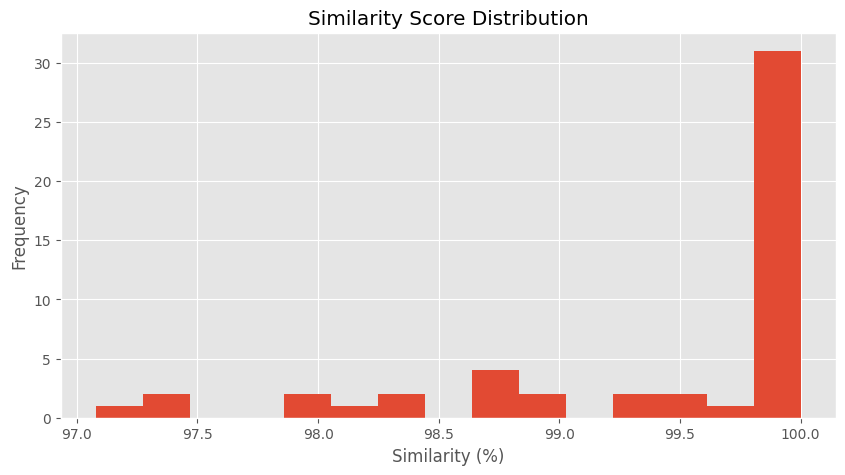

In [93]:
# ============================================================
# Similarity Distribution
# ============================================================

similarity_values = []

for book in test_books:

    rec = recommend_books(book, top_n=10)

    if rec is not None:

        similarity_values.extend(
            rec["Similarity"].tolist()
        )

plt.figure(figsize=(10,5))

plt.hist(
    similarity_values,
    bins=15
)

plt.title("Similarity Score Distribution")

plt.xlabel("Similarity (%)")

plt.ylabel("Frequency")

plt.show()

In [94]:
# ============================================================
# Measure Prediction Time
# ============================================================

start = time.time()

recommend_books(
    "Harry Potter",
    top_n=10
)

end = time.time()

print(f"Inference Time : {(end-start)*1000:.2f} ms")

Inference Time : 850.20 ms


In [95]:
# ============================================================
# Average Prediction Time
# ============================================================

times = []

for book in test_books:

    start = time.time()

    recommend_books(book)

    end = time.time()

    times.append(
        (end-start)*1000
    )

print(f"Average Time : {np.mean(times):.2f} ms")

print(f"Minimum Time : {np.min(times):.2f} ms")

print(f"Maximum Time : {np.max(times):.2f} ms")

Average Time : 663.81 ms
Minimum Time : 449.33 ms
Maximum Time : 913.40 ms


In [96]:
# ============================================================
# Recommendation Diversity
# ============================================================

recommended = []

for book in test_books:

    rec = recommend_books(book)

    if rec is not None:

        recommended.extend(
            rec["Title"]
        )

unique_books = len(set(recommended))

print("Total Recommendations :", len(recommended))

print("Unique Recommendations :", unique_books)

print("Diversity :", unique_books/len(recommended))

Total Recommendations : 50
Unique Recommendations : 48
Diversity : 0.96


In [97]:
# ============================================================
# Catalog Coverage
# ============================================================

coverage = (
    unique_books
    /
    len(model_df)
) * 100

print(f"Coverage : {coverage:.2f}%")

Coverage : 0.43%


In [98]:
# ============================================================
# Recommendation Count
# ============================================================

recommendations = recommend_books(
    "Harry Potter",
    top_n=15
)

print(
    "Returned Recommendations :",
    len(recommendations)
)

Returned Recommendations : 15


In [99]:
# ============================================================
# Evaluation Report
# ============================================================

evaluation = pd.DataFrame({

    "Metric":[
        "Average Similarity",
        "Average Time (ms)",
        "Coverage (%)"
    ],

    "Value":[
        np.mean(scores),
        np.mean(times),
        coverage
    ]

})

evaluation

,Metric,Value
0,Average Similarity,99.452400
1,Average Time (ms),663.811779
2,Coverage (%),0.431538


In [100]:
# ============================================================
# Export Report
# ============================================================

evaluation.to_csv(
    "evaluation_report.csv",
    index=False
)

print("Evaluation report exported.")

Evaluation report exported.


In [101]:
# ============================================================
# Model Summary
# ============================================================

print("="*70)

print("BOOK RECOMMENDATION SYSTEM")

print("="*70)

print(f"Dataset Size          : {len(model_df):,}")

print(f"Feature Count         : {scaled_features.shape[1]}")

print(f"Recommendation Model  : K-Nearest Neighbors")

print(f"Similarity Metric     : Cosine Distance")

print(f"Neighbors             : 10")

print(f"Average Similarity    : {np.mean(scores):.2f}%")

print(f"Average Inference     : {np.mean(times):.2f} ms")

print("="*70)

BOOK RECOMMENDATION SYSTEM
Dataset Size          : 11,123
Feature Count         : 41
Recommendation Model  : K-Nearest Neighbors
Similarity Metric     : Cosine Distance
Neighbors             : 10
Average Similarity    : 99.45%
Average Inference     : 663.81 ms
